# TS2Vec Event Detection — Per-Timestamp Embeddings

Use **TS2Vec** (timestamp-level contrastive learning) to learn embeddings at every point in the stream, then cluster/classify to find where flow events happen.

Pipeline:
1. Fetch last 5min of x-axis data from sensor 6
2. Create overlapping 25s sliding windows for training
3. Train TS2Vec encoder (unsupervised)
4. Get per-timestamp embeddings for the full series
5. Cluster embeddings to find event vs. normal periods
6. Visualize the embedding space + detected events

In [1]:
import subprocess, sys
subprocess.check_call([sys.executable, "-m", "pip", "install",
    "requests", "numpy", "pandas", "matplotlib", "scikit-learn", "torch", "ts2vec"])

  Using cached networkx-3.4.2-py3-none-any.whl.metadata (6.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.5/80.5 MB 5.6 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 5.7 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 6.0 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 536.2/536.2 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9/9 [torch]32m8/9 [torch]kx]



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: /opt/homebrew/opt/python@3.10/bin/python3.10 -m pip install --upgrade pip


0

In [2]:
import requests
import numpy as np
import pandas as pd
from datetime import datetime, timezone, timedelta
import matplotlib.pyplot as plt

HASURA_URL = "https://hasura.pipestuesday.org/v1/graphql"
HASURA_ADMIN_SECRET = "PIPE_SUPERMMMSECRET_PIPE"
HEADERS = {
    "Content-Type": "application/json",
    "x-hasura-admin-secret": HASURA_ADMIN_SECRET,
}

def gql_query(query: str, variables: dict = None) -> dict:
    payload = {"query": query}
    if variables:
        payload["variables"] = variables
    resp = requests.post(HASURA_URL, json=payload, headers=HEADERS)
    resp.raise_for_status()
    body = resp.json()
    if "errors" in body:
        raise RuntimeError(f"GraphQL errors: {body['errors']}")
    return body["data"]

print("Hasura client ready")

Hasura client ready


## 1. Fetch Last 5min of X-Axis Data

In [3]:
SENSOR_ID = 6
MINUTES_BACK = 5

now = datetime.now(timezone.utc)
since = now - timedelta(minutes=MINUTES_BACK)

mag_data = gql_query("""
query GetMag($sensor_id: bigint!, $since: timestamptz!) {
  mag_report(
    where: {
      sensor_id: {_eq: $sensor_id}
      created_at: {_gte: $since}
    }
    order_by: {created_at: asc}
    limit: 100000
  ) {
    created_at
    x_axis_reading
  }
}
""", variables={"sensor_id": str(SENSOR_ID), "since": since.isoformat()})

reports = mag_data["mag_report"]
print(f"Sensor {SENSOR_ID}: {len(reports)} readings in last {MINUTES_BACK}min")

if len(reports) == 0:
    print("No recent data — fetching the last available window instead...")
    latest = gql_query("""
    query Latest($sid: bigint!) {
      mag_report(where: {sensor_id: {_eq: $sid}}, order_by: {created_at: desc}, limit: 1) {
        created_at
      }
    }
    """, variables={"sid": str(SENSOR_ID)})["mag_report"]

    if latest:
        end_time = pd.to_datetime(latest[0]["created_at"])
        start_time = end_time - timedelta(minutes=MINUTES_BACK)
        print(f"  Using window: {start_time} -> {end_time}")

        reports = gql_query("""
        query GetMag($sensor_id: bigint!, $since: timestamptz!, $until: timestamptz!) {
          mag_report(
            where: {
              sensor_id: {_eq: $sensor_id}
              created_at: {_gte: $since, _lte: $until}
            }
            order_by: {created_at: asc}
            limit: 100000
          ) {
            created_at
            x_axis_reading
          }
        }
        """, variables={"sensor_id": str(SENSOR_ID),
                        "since": start_time.isoformat(),
                        "until": end_time.isoformat()})["mag_report"]
        print(f"  Got {len(reports)} readings")
    else:
        raise RuntimeError(f"Sensor {SENSOR_ID} has no data at all!")

df = pd.DataFrame(reports)
df["created_at"] = pd.to_datetime(df["created_at"], format="ISO8601")
df["x_axis_reading"] = pd.to_numeric(df["x_axis_reading"], errors="coerce")

print(f"Time range: {df['created_at'].min()} -> {df['created_at'].max()}")
print(f"Sample rate: ~{len(df) / MINUTES_BACK / 60:.1f} Hz")
df.head()

Sensor 6: 2945 readings in last 5min
Time range: 2026-03-29 21:43:31.852000+00:00 -> 2026-03-29 21:48:29.554000+00:00
Sample rate: ~9.8 Hz


,created_at,x_axis_reading
0,2026-03-29 21:43:31.852000+00:00,-477
1,2026-03-29 21:43:31.952000+00:00,-478
2,2026-03-29 21:43:32.052000+00:00,-476
3,2026-03-29 21:43:32.152000+00:00,-474
4,2026-03-29 21:43:32.252000+00:00,-478


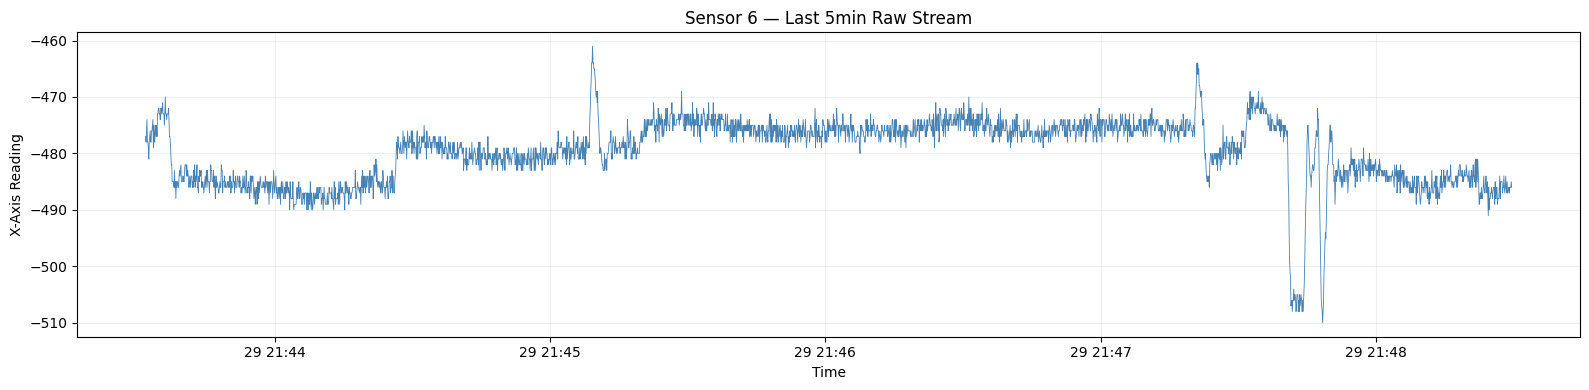

In [4]:
# Quick look at the raw signal
fig, ax = plt.subplots(figsize=(16, 4))
ax.plot(df["created_at"], df["x_axis_reading"], lw=0.6, color="steelblue")
ax.set_ylabel("X-Axis Reading")
ax.set_title(f"Sensor {SENSOR_ID} — Last {MINUTES_BACK}min Raw Stream")
ax.set_xlabel("Time")
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

## 2. Create Sliding Windows (25s)

Slide a 25-second window over the continuous stream to create overlapping training samples for TS2Vec. These are unlabeled — TS2Vec learns via contrastive self-supervision.

In [5]:
WINDOW_SECONDS = 25
STRIDE_SECONDS = 5  # overlap: slide by 5s each step

# Compute sample rate from the data
total_seconds = (df["created_at"].max() - df["created_at"].min()).total_seconds()
sample_rate = len(df) / total_seconds
print(f"Estimated sample rate: {sample_rate:.2f} Hz")

window_len = int(WINDOW_SECONDS * sample_rate)
stride_len = int(STRIDE_SECONDS * sample_rate)
print(f"Window length: {window_len} samples, stride: {stride_len} samples")

# Z-normalize the full series
series = df["x_axis_reading"].dropna().values.astype(np.float32)
series_mean = series.mean()
series_std = series.std()
series_z = (series - series_mean) / max(series_std, 1e-8)

# Create sliding windows
windows = []
for start in range(0, len(series_z) - window_len + 1, stride_len):
    windows.append(series_z[start:start + window_len])

windows = np.array(windows)
# TS2Vec expects shape: (n_samples, seq_len, n_features)
windows_3d = windows[:, :, np.newaxis]

print(f"Created {len(windows)} overlapping windows of {WINDOW_SECONDS}s each")
print(f"Training data shape: {windows_3d.shape}")

Estimated sample rate: 9.89 Hz
Window length: 247 samples, stride: 49 samples
Created 56 overlapping windows of 25s each
Training data shape: (56, 247, 1)


## 3. Train TS2Vec Encoder

Train the contrastive encoder on the sliding windows. This is fully unsupervised — it learns to produce similar embeddings for nearby timestamps and different embeddings for distant ones.

In [6]:
from ts2vec import TS2Vec
import torch

device = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
print(f"Using device: {device}")

model = TS2Vec(
    input_dims=1,
    device=device,
    output_dims=320,   # embedding dimension
    hidden_dims=64,
    depth=10,
    lr=0.001,
)

model.fit(windows_3d, n_epochs=200, verbose=True)
print("Training complete")

Using device: mps
Epoch #0: loss=14.88861083984375
Epoch #1: loss=4.76166303952535
Epoch #2: loss=3.8397138913472495
Epoch #3: loss=3.43172025680542
Epoch #4: loss=3.0495147705078125
Epoch #5: loss=3.0490240255991616
Epoch #6: loss=2.75490132967631
Epoch #7: loss=2.8729523022969565
Epoch #8: loss=2.8848915894826255
Epoch #9: loss=2.907221714655558
Epoch #10: loss=2.5774803161621094
Epoch #11: loss=2.916449546813965
Epoch #12: loss=2.8129804134368896
Epoch #13: loss=2.5386850833892822
Epoch #14: loss=2.594590663909912
Epoch #15: loss=2.6688689390818277
Epoch #16: loss=2.7330458958943686
Epoch #17: loss=2.588052272796631
Epoch #18: loss=2.797564665476481
Epoch #19: loss=2.8171581427256265
Epoch #20: loss=2.747695207595825
Epoch #21: loss=2.7547155221303306
Epoch #22: loss=2.5584683418273926
Epoch #23: loss=2.6533333460489907
Epoch #24: loss=2.5185431639353433
Epoch #25: loss=2.531426032384237
Epoch #26: loss=2.4440629482269287
Epoch #27: loss=2.4547248681386313
Epoch #28: loss=2.57113949

## 4. Per-Timestamp Embeddings

Encode the full continuous series to get a 320-dim embedding at every single timestamp. This is the key advantage of TS2Vec — no window-size commitment at inference time.

In [11]:
# Encode per-timestamp: slide the same training windows over the full series
# and get the embedding at the LAST timestamp of each window.
# Then also encode with smaller windows to fill in the gaps.

full_series = series_z[np.newaxis, :, np.newaxis]

# Try timestamp-level encoding first
embeddings = model.encode(full_series)
print(f"Raw encoder output shape: {embeddings.shape}")

if embeddings.ndim == 3:
    embeddings = embeddings.squeeze(0)  # (total_length, embed_dim)

# If it collapsed to (1, embed_dim) or (embed_dim,), we need a different approach
if embeddings.ndim == 1 or (embeddings.ndim == 2 and embeddings.shape[0] == 1):
    print("Timestamp-level encoding not available — encoding sliding windows instead...")
    
    # Encode each sliding window, take the embedding of the center timestamp
    stride = max(1, stride_len // 2)
    emb_list = []
    emb_indices = []
    
    for start in range(0, len(series_z) - window_len + 1, stride):
        chunk = series_z[start:start + window_len]
        chunk_3d = chunk[np.newaxis, :, np.newaxis]  # (1, window_len, 1)
        enc = model.encode(chunk_3d)
        if enc.ndim == 3:
            enc = enc.squeeze(0)  # (window_len, embed_dim) or (1, embed_dim)
        
        if enc.ndim == 2 and enc.shape[0] > 1:
            # Got per-timestamp within the window — take the center
            mid = window_len // 2
            emb_list.append(enc[mid])
            emb_indices.append(start + mid)
        else:
            # Got one embedding per window — assign to center timestamp
            emb_list.append(enc.flatten())
            emb_indices.append(start + window_len // 2)
    
    emb_array = np.array(emb_list)
    emb_indices = np.array(emb_indices)
    
    # Interpolate to get embeddings for ALL timestamps
    from scipy.interpolate import interp1d
    embed_dim = emb_array.shape[1]
    embeddings = np.zeros((len(series_z), embed_dim))
    for d in range(embed_dim):
        f = interp1d(emb_indices, emb_array[:, d], kind="linear",
                     fill_value="extrapolate")
        embeddings[:, d] = f(np.arange(len(series_z)))
    
    print(f"Interpolated to full series: {embeddings.shape}")
else:
    print(f"Got per-timestamp embeddings: {embeddings.shape}")

print(f"Final: {embeddings.shape[0]} timestamps x {embeddings.shape[1]} dims")

Raw encoder output shape: (1, 2945, 320)
Got per-timestamp embeddings: (2945, 320)
Final: 2945 timestamps x 320 dims


## 5. Cluster Timestamp Embeddings

K-Means on the 320-dim embeddings to separate "event" timestamps from "normal/quiet" timestamps. Timestamps during flow events should naturally cluster together.

In [12]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

N_CLUSTERS = 2  # event vs normal — increase if you expect multiple event types

kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=10)
labels = kmeans.fit_predict(embeddings)

# Figure out which cluster is "event" vs "normal" by checking mean signal amplitude per cluster
for c in range(N_CLUSTERS):
    mask = labels == c
    mean_amp = np.mean(np.abs(series_z[mask]))
    count = mask.sum()
    print(f"  Cluster {c}: {count} timestamps, mean |amplitude| = {mean_amp:.3f}")

# The cluster with higher mean amplitude is likely the "event" cluster
cluster_amps = [np.mean(np.abs(series_z[labels == c])) for c in range(N_CLUSTERS)]
event_cluster = np.argmax(cluster_amps)
print(f"\nEvent cluster: {event_cluster} (highest amplitude)")

# Binary event mask
is_event = (labels == event_cluster).astype(int)
print(f"Event timestamps: {is_event.sum()} / {len(is_event)} ({100*is_event.mean():.1f}%)")

  Cluster 0: 1552 timestamps, mean |amplitude| = 0.914
  Cluster 1: 1393 timestamps, mean |amplitude| = 0.647

Event cluster: 0 (highest amplitude)
Event timestamps: 1552 / 2945 (52.7%)


## 6. Visualize — Signal with Detected Events

The key plot: raw signal with event regions highlighted. Change points are where the cluster label switches.

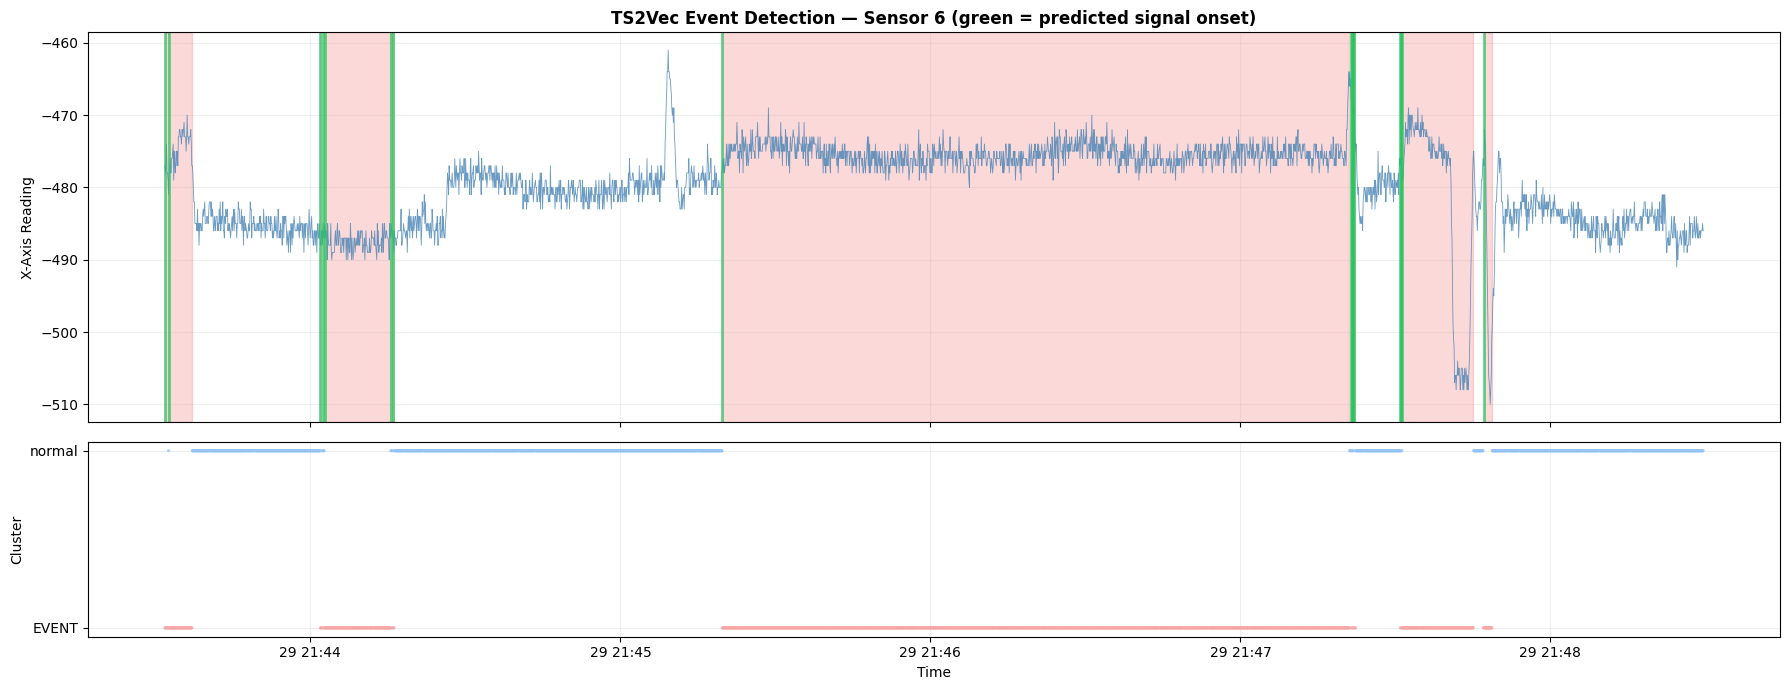

In [13]:
timestamps = df.loc[df["x_axis_reading"].notna(), "created_at"].values
ts_plot = pd.to_datetime(timestamps)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(18, 7), sharex=True,
                                gridspec_kw={"height_ratios": [2, 1]})

# Top: signal with event regions shaded
ax1.plot(ts_plot, series, lw=0.6, color="steelblue", alpha=0.8)

# Shade event regions
in_event = False
event_start = None
for i in range(len(is_event)):
    if is_event[i] and not in_event:
        event_start = i
        in_event = True
    elif not is_event[i] and in_event:
        ax1.axvspan(ts_plot[event_start], ts_plot[i - 1], color="#ef4444", alpha=0.2)
        ax1.axvline(ts_plot[event_start], color="#22c55e", lw=2, ls="-", alpha=0.7)
        in_event = False
if in_event:  # still in event at end of series
    ax1.axvspan(ts_plot[event_start], ts_plot[-1], color="#ef4444", alpha=0.2)
    ax1.axvline(ts_plot[event_start], color="#22c55e", lw=2, ls="-", alpha=0.7)

ax1.set_ylabel("X-Axis Reading")
ax1.set_title(f"TS2Vec Event Detection — Sensor {SENSOR_ID} (green = predicted signal onset)", fontweight="bold")
ax1.grid(True, alpha=0.2)

# Bottom: cluster labels over time
colors = ["#93c5fd" if l != event_cluster else "#fca5a5" for l in labels]
ax2.scatter(ts_plot, labels, c=colors, s=2, alpha=0.6)
ax2.set_ylabel("Cluster")
ax2.set_xlabel("Time")
ax2.set_yticks(range(N_CLUSTERS))
ax2.set_yticklabels([f"{'EVENT' if c == event_cluster else 'normal'}" for c in range(N_CLUSTERS)])
ax2.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

## 7. Embedding Space Visualization (PCA + t-SNE)

Reduce the 320-dim embeddings to 2D to see how well event vs. normal timestamps separate in the learned space.

PCA explained variance: 57.9%


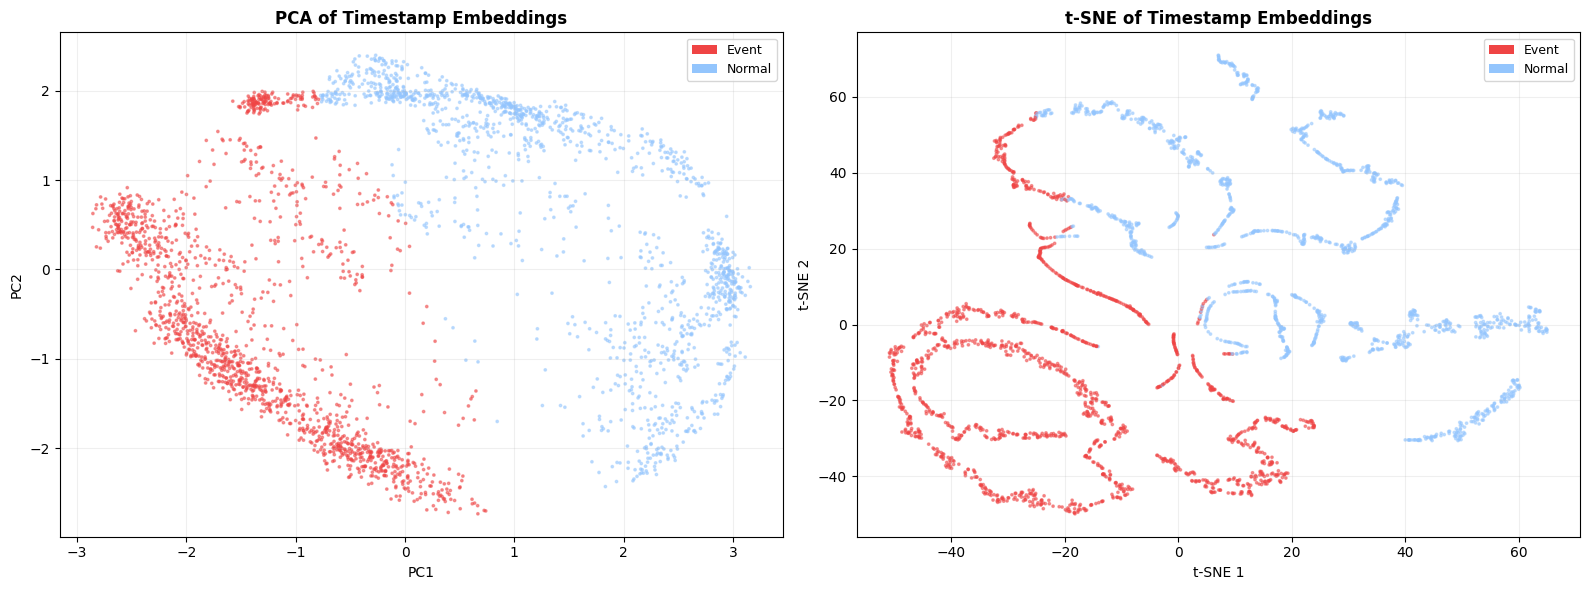

In [14]:
from sklearn.manifold import TSNE

# PCA to 2D
pca = PCA(n_components=2)
emb_pca = pca.fit_transform(embeddings)
print(f"PCA explained variance: {pca.explained_variance_ratio_.sum():.1%}")

# t-SNE to 2D (subsample if too many points)
MAX_TSNE = 3000
if len(embeddings) > MAX_TSNE:
    idx = np.random.choice(len(embeddings), MAX_TSNE, replace=False)
    idx.sort()
    emb_tsne = TSNE(n_components=2, perplexity=30, random_state=42).fit_transform(embeddings[idx])
    labels_tsne = labels[idx]
else:
    emb_tsne = TSNE(n_components=2, perplexity=30, random_state=42).fit_transform(embeddings)
    labels_tsne = labels

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# PCA
scatter_colors = ["#93c5fd" if l != event_cluster else "#ef4444" for l in labels]
ax1.scatter(emb_pca[:, 0], emb_pca[:, 1], c=scatter_colors, s=3, alpha=0.5)
ax1.set_title("PCA of Timestamp Embeddings", fontweight="bold")
ax1.set_xlabel("PC1")
ax1.set_ylabel("PC2")
ax1.grid(True, alpha=0.2)

# t-SNE
scatter_colors_tsne = ["#93c5fd" if l != event_cluster else "#ef4444" for l in labels_tsne]
ax2.scatter(emb_tsne[:, 0], emb_tsne[:, 1], c=scatter_colors_tsne, s=3, alpha=0.5)
ax2.set_title("t-SNE of Timestamp Embeddings", fontweight="bold")
ax2.set_xlabel("t-SNE 1")
ax2.set_ylabel("t-SNE 2")
ax2.grid(True, alpha=0.2)

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor="#ef4444", label="Event"),
                   Patch(facecolor="#93c5fd", label="Normal")]
ax1.legend(handles=legend_elements, fontsize=9)
ax2.legend(handles=legend_elements, fontsize=9)

plt.tight_layout()
plt.show()

## 8. Embedding Shift as Event Signal

Instead of clustering, look at how fast the embedding changes over time. Large shifts in the embedding space = likely event boundaries (change points in the learned representation).

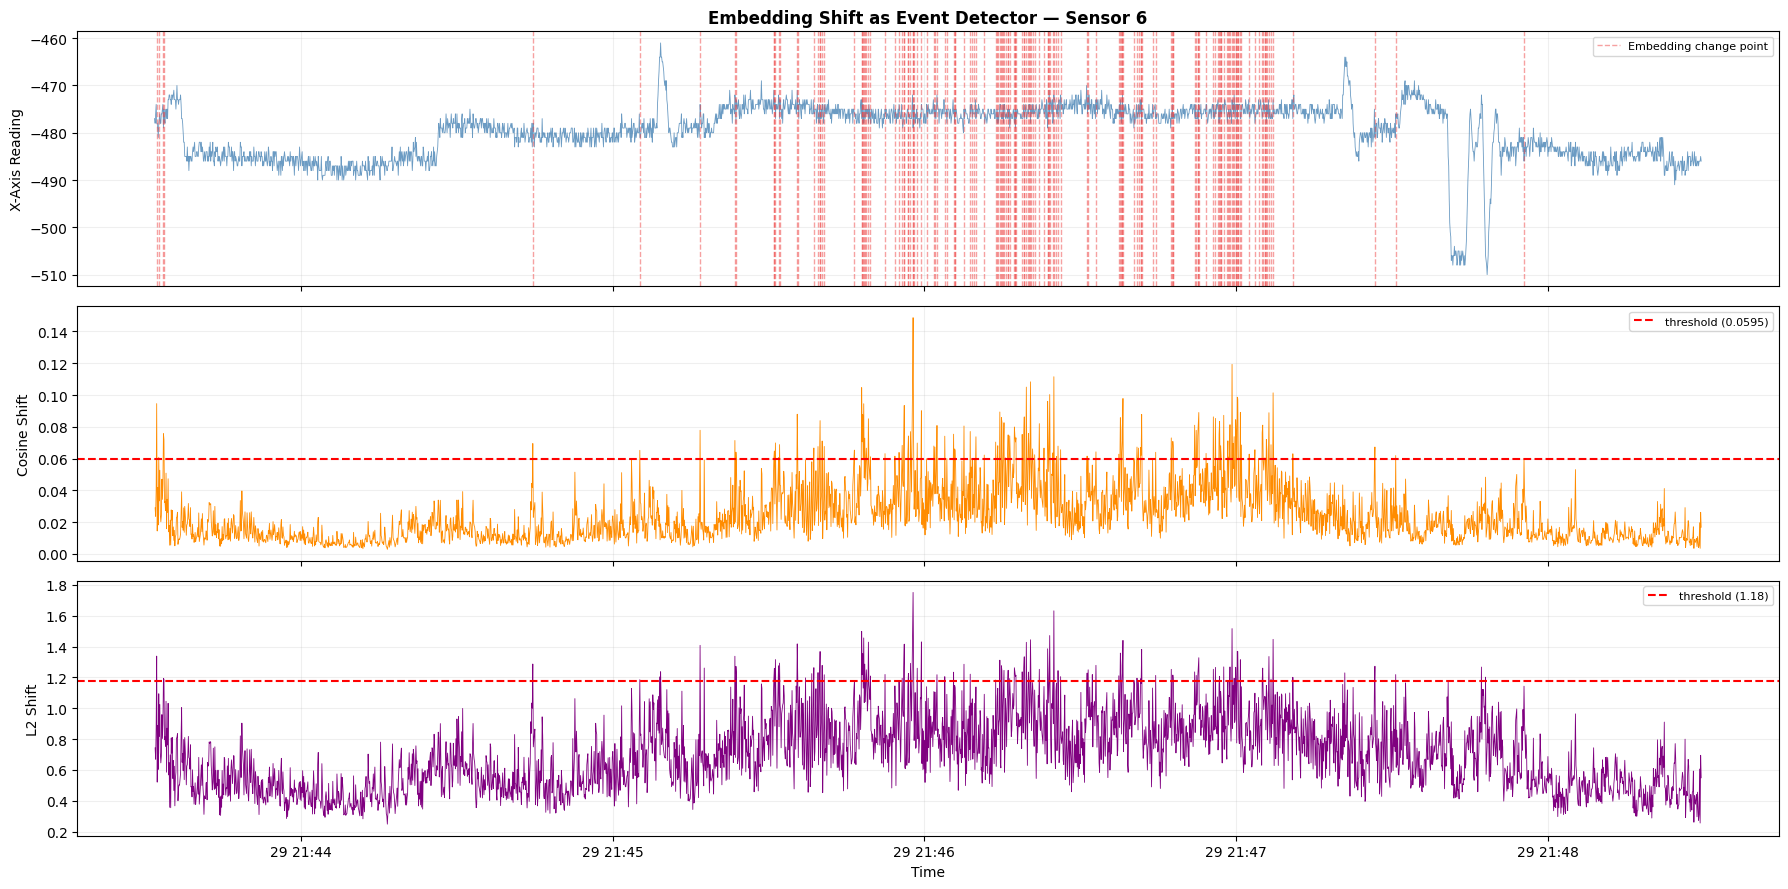

Cosine shift detected 162 boundary points
L2 shift detected 119 boundary points


In [15]:
# Cosine distance between consecutive timestamp embeddings
from numpy.linalg import norm

emb_norm = embeddings / (norm(embeddings, axis=1, keepdims=True) + 1e-8)
cosine_shift = 1 - np.sum(emb_norm[:-1] * emb_norm[1:], axis=1)

# Also L2 distance
l2_shift = norm(np.diff(embeddings, axis=0), axis=1)

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(18, 9), sharex=True)

# Raw signal
ax1.plot(ts_plot, series, lw=0.6, color="steelblue", alpha=0.8)
ax1.set_ylabel("X-Axis Reading")
ax1.set_title(f"Embedding Shift as Event Detector — Sensor {SENSOR_ID}", fontweight="bold")
ax1.grid(True, alpha=0.2)

# Cosine shift
ax2.plot(ts_plot[1:], cosine_shift, lw=0.6, color="darkorange")
# Threshold: mean + 2*std
cos_thresh = np.mean(cosine_shift) + 2 * np.std(cosine_shift)
ax2.axhline(cos_thresh, color="red", ls="--", lw=1.5, label=f"threshold ({cos_thresh:.4f})")
ax2.set_ylabel("Cosine Shift")
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.2)

# Mark detected change points on the signal
cos_cps = np.where(cosine_shift > cos_thresh)[0] + 1
for i, idx in enumerate(cos_cps):
    label = "Embedding change point" if i == 0 else None
    ax1.axvline(ts_plot[idx], color="#ef4444", lw=1, ls="--", alpha=0.5, label=label)
if cos_cps.size > 0:
    ax1.legend(fontsize=8)

# L2 shift
ax3.plot(ts_plot[1:], l2_shift, lw=0.6, color="purple")
l2_thresh = np.mean(l2_shift) + 2 * np.std(l2_shift)
ax3.axhline(l2_thresh, color="red", ls="--", lw=1.5, label=f"threshold ({l2_thresh:.2f})")
ax3.set_ylabel("L2 Shift")
ax3.set_xlabel("Time")
ax3.legend(fontsize=8)
ax3.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

print(f"Cosine shift detected {len(cos_cps)} boundary points")
print(f"L2 shift detected {np.sum(l2_shift > l2_thresh)} boundary points")

## 9. Event Summary

List all detected events with their start/end times and durations.

In [16]:
# Extract contiguous event regions from the cluster labels
events = []
in_event = False
for i in range(len(is_event)):
    if is_event[i] and not in_event:
        start_i = i
        in_event = True
    elif not is_event[i] and in_event:
        events.append({"start_idx": start_i, "end_idx": i - 1})
        in_event = False
if in_event:
    events.append({"start_idx": start_i, "end_idx": len(is_event) - 1})

print(f"Detected {len(events)} event(s):\n")
print(f"{'Event':<8} {'Start':<25} {'End':<25} {'Duration (s)':>12} {'Samples':>8}")
print("-" * 80)
for i, ev in enumerate(events):
    t0 = pd.Timestamp(timestamps[ev["start_idx"]])
    t1 = pd.Timestamp(timestamps[ev["end_idx"]])
    dur = (t1 - t0).total_seconds()
    n = ev["end_idx"] - ev["start_idx"] + 1
    print(f"{i+1:<8} {str(t0):<25} {str(t1):<25} {dur:>12.1f} {n:>8}")

Detected 16 event(s):

Event    Start                     End                       Duration (s)  Samples
--------------------------------------------------------------------------------
1        2026-03-29 21:43:31.852000 2026-03-29 21:43:32.452000          0.6        7
2        2026-03-29 21:43:32.652000 2026-03-29 21:43:37.052000          4.4       45
3        2026-03-29 21:44:01.952000 2026-03-29 21:44:02.152000          0.2        3
4        2026-03-29 21:44:02.452000 2026-03-29 21:44:02.452000          0.0        1
5        2026-03-29 21:44:02.752000 2026-03-29 21:44:15.452000         12.7      126
6        2026-03-29 21:44:15.652000 2026-03-29 21:44:15.652000          0.0        1
7        2026-03-29 21:44:15.952000 2026-03-29 21:44:16.152000          0.2        3
8        2026-03-29 21:45:19.753000 2026-03-29 21:47:21.054000        121.3     1204
9        2026-03-29 21:47:21.454000 2026-03-29 21:47:21.454000          0.0        1
10       2026-03-29 21:47:21.654000 2026-03-29 2